In [1]:
import os
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))
os.chdir('C:/Users/Tom/Desktop/east_africa_conflict_analysis/')

Current working directory: c:\Users\Tom\Desktop\east_africa_conflict_analysis\notebooks
Files in current directory: ['exploratory_data_analysis.ipynb', 'explore_model_outputs.ipynb']


In [2]:
# --- 1. Imports ---
from src.data_cleaning import clean_data_pipeline
from src.feature_engineering import feature_engineering_pipeline
from src.modelling import run_gwr_pipeline
import matplotlib.pyplot as plt
import geopandas as gpd

# --- 2. Load your processed GeoDataFrame ---
data = clean_data_pipeline()
data = feature_engineering_pipeline(data)

gdf = data['ken']['features']

# --- 3. Run GWR pipeline ---
gdf_gwr, gwr_results, bw = run_gwr_pipeline(
    gdf,
    y_var='log_conflict_rate',   # dependent variable (logged)
    x_vars=['police_per_10k'],            # independent variable(s)
    standardize=True,                     # recommended
    kernel='gaussian',                    # default kernel
    auto_select_bw=True                   # let MGWR choose bandwidth
)

print(f"Selected bandwidth: {bw}")
print(gwr_results.summary())



Starting data cleaning pipeline...
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ken_police.parquet
Replaced 100583464 missing values (-99999.0) with 0 in ken - population
Data cleaning complete.
Starting feature engineering pipeline for: ken
  - Spatially joining ACLED events to admin units...
  - Spatially joining police stations to admin units...
  -> Aggregation complete: conflict_count & police_count added.
Adding population from raster to admin units...
  - Population raster CRS: EPSG:32637
  - Running zonal statistics (sum of population per unit). This may take a moment...
  -> Population added to features (NaN for zero-pop units).
Creating rates and densities...
  -> Rates & log-transforms created.
Feature engineering pipeline complete.
[modeling] Running baseline OLS for comparison...
[modeling] Running OLS: log_conflict_rate ~ police_per_10k
[modeling] OLS complete.
[modeling] OLS R-squared: 0.0016
[modeling] Selecting bandwidth (this may take a momen

<Figure size 800x600 with 0 Axes>

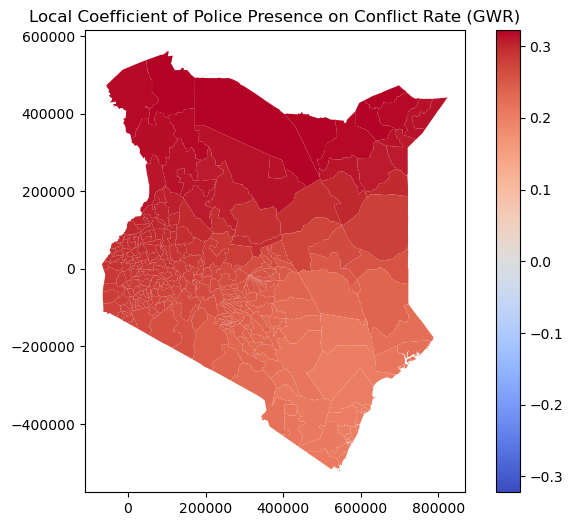

In [3]:
plt.figure(figsize=(8, 6))

# Calculate symmetric bounds around 0
max_abs_value = max(abs(gdf_gwr['gwr_police_per_10k_coef'].min()), 
                    abs(gdf_gwr['gwr_police_per_10k_coef'].max()))

gdf_gwr.plot(column='gwr_police_per_10k_coef',
             legend=True,
             cmap='coolwarm',
             figsize=(8,6),
             vmin=-max_abs_value,
             vmax=max_abs_value)
plt.title('Local Coefficient of Police Presence on Conflict Rate (GWR)')
plt.show()


<Figure size 800x600 with 0 Axes>

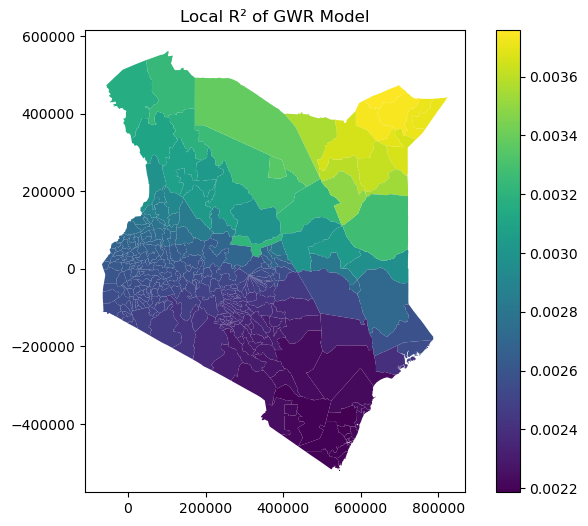

In [4]:
plt.figure(figsize=(8, 6))
gdf_gwr.plot(column='gwr_local_R2',
             legend=True,
             cmap='viridis',
             figsize=(8,6))
plt.title('Local R² of GWR Model')
plt.show()


<Figure size 800x600 with 0 Axes>

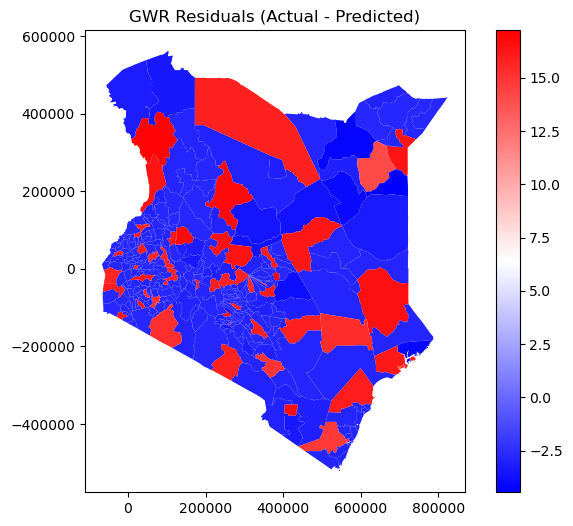

In [5]:
plt.figure(figsize=(8, 6))
gdf_gwr.plot(column='gwr_gwr_resid',
             legend=True,
             cmap='bwr',
             figsize=(8,6))
plt.title('GWR Residuals (Actual - Predicted)')
plt.show()


In [6]:
import numpy as np
import statsmodels.api as sm

# 1. Extract variables
y = gdf["log_conflict_rate"]  # dependent variable
X = gdf[["log_police_density"]]  # independent variable

# 2. Add constant
X_const = sm.add_constant(X)

# 3. Fit OLS
ols_model = sm.OLS(y, X_const).fit()

# 4. Extract OLS AIC (statsmodels gives AIC, not AICc)
ols_aic = ols_model.aic
n = len(y)
k = len(ols_model.params)  # number of parameters (including intercept)

# 5. Compute AICc manually
ols_aicc = ols_aic + (2 * k * (k + 1)) / (n - k - 1)

print(f"OLS AIC:  {ols_aic:.3f}")
print(f"OLS AICc: {ols_aicc:.3f}")


OLS AIC:  2013.214
OLS AICc: 2013.255


In [7]:
gwr_aicc = gwr_results.aicc
print(f"GWR AICc: {gwr_aicc:.3f}")


GWR AICc: 2015.351


In [8]:
print(f"OLS AICc: {ols_aicc:.3f}")
print(f"GWR AICc: {gwr_aicc:.3f}")
print(f"Difference: {ols_aicc - gwr_aicc:.3f}")


OLS AICc: 2013.255
GWR AICc: 2015.351
Difference: -2.096
